# [LAB 06] 데이터 시각화 - 7. Heatmap 

## #01. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import * 
from pandas import pivot_table
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 

In [2]:
origin = load_data('flights')
origin

📚 어느 항공사의 년/월별 국제선 탑승객 수(출처: seaborn 내장 데이터)


,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121
...,...,...,...
139,1960,August,606
140,1960,September,508
141,1960,October,461
142,1960,November,390


### 3. 데이터 전처리 (1) 
- 영문 월 이름을 숫자로 변환 

In [3]:
df = origin.copy()
df['month'] = df['month'].map({
    "January":1, "February":2,"March":3, "April":4, 
    "May":5, "June":6, "July":7, "August":8, 
    "September":9,"October":10, "November":11, "December":12
})

df.head()

,year,month,passengers
0,1949,1,112
1,1949,2,118
2,1949,3,132
3,1949,4,129
4,1949,5,121


### 4. 데이터 전처리 (2) 
- 히트맵에 적합한 형태로 데이터 재구조화 
    - 히트맵은 피벗 테이블 형태의 테이블을 시각화 한다. 

In [4]:
df2 = pivot_table(df, index="year", columns="month", values="passengers")
df2

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1949,112.000,118.000,132.000,129.000,121.000,135.000,148.000,148.000,136.000,119.000,104.000,118.000
1950,115.000,126.000,141.000,135.000,125.000,149.000,170.000,170.000,158.000,133.000,114.000,140.000
1951,145.000,150.000,178.000,163.000,172.000,178.000,199.000,199.000,184.000,162.000,146.000,166.000
1952,171.000,180.000,193.000,181.000,183.000,218.000,230.000,242.000,209.000,191.000,172.000,194.000
1953,196.000,196.000,236.000,235.000,229.000,243.000,264.000,272.000,237.000,211.000,180.000,201.000
1954,204.000,188.000,235.000,227.000,234.000,264.000,302.000,293.000,259.000,229.000,203.000,229.000
1955,242.000,233.000,267.000,269.000,270.000,315.000,364.000,347.000,312.000,274.000,237.000,278.000
1956,284.000,277.000,317.000,313.000,318.000,374.000,413.000,405.000,355.000,306.000,271.000,306.000
1957,315.000,301.000,356.000,348.000,355.000,422.000,465.000,467.000,404.000,347.000,305.000,336.000


### 5. 데이터 전처리 (3) 
- 년도 역순으로 정렬 

In [5]:
df3 = df2.sort_index(ascending=False)
df3

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1960,417.000,391.000,419.000,461.000,472.000,535.000,622.000,606.000,508.000,461.000,390.000,432.000
1959,360.000,342.000,406.000,396.000,420.000,472.000,548.000,559.000,463.000,407.000,362.000,405.000
1958,340.000,318.000,362.000,348.000,363.000,435.000,491.000,505.000,404.000,359.000,310.000,337.000
1957,315.000,301.000,356.000,348.000,355.000,422.000,465.000,467.000,404.000,347.000,305.000,336.000
1956,284.000,277.000,317.000,313.000,318.000,374.000,413.000,405.000,355.000,306.000,271.000,306.000
1955,242.000,233.000,267.000,269.000,270.000,315.000,364.000,347.000,312.000,274.000,237.000,278.000
1954,204.000,188.000,235.000,227.000,234.000,264.000,302.000,293.000,259.000,229.000,203.000,229.000
1953,196.000,196.000,236.000,235.000,229.000,243.000,264.000,272.000,237.000,211.000,180.000,201.000
1952,171.000,180.000,193.000,181.000,183.000,218.000,230.000,242.000,209.000,191.000,172.000,194.000


## #02. Heatmap 시각화 

findfont: Failed to find font weight 500, now using 400.


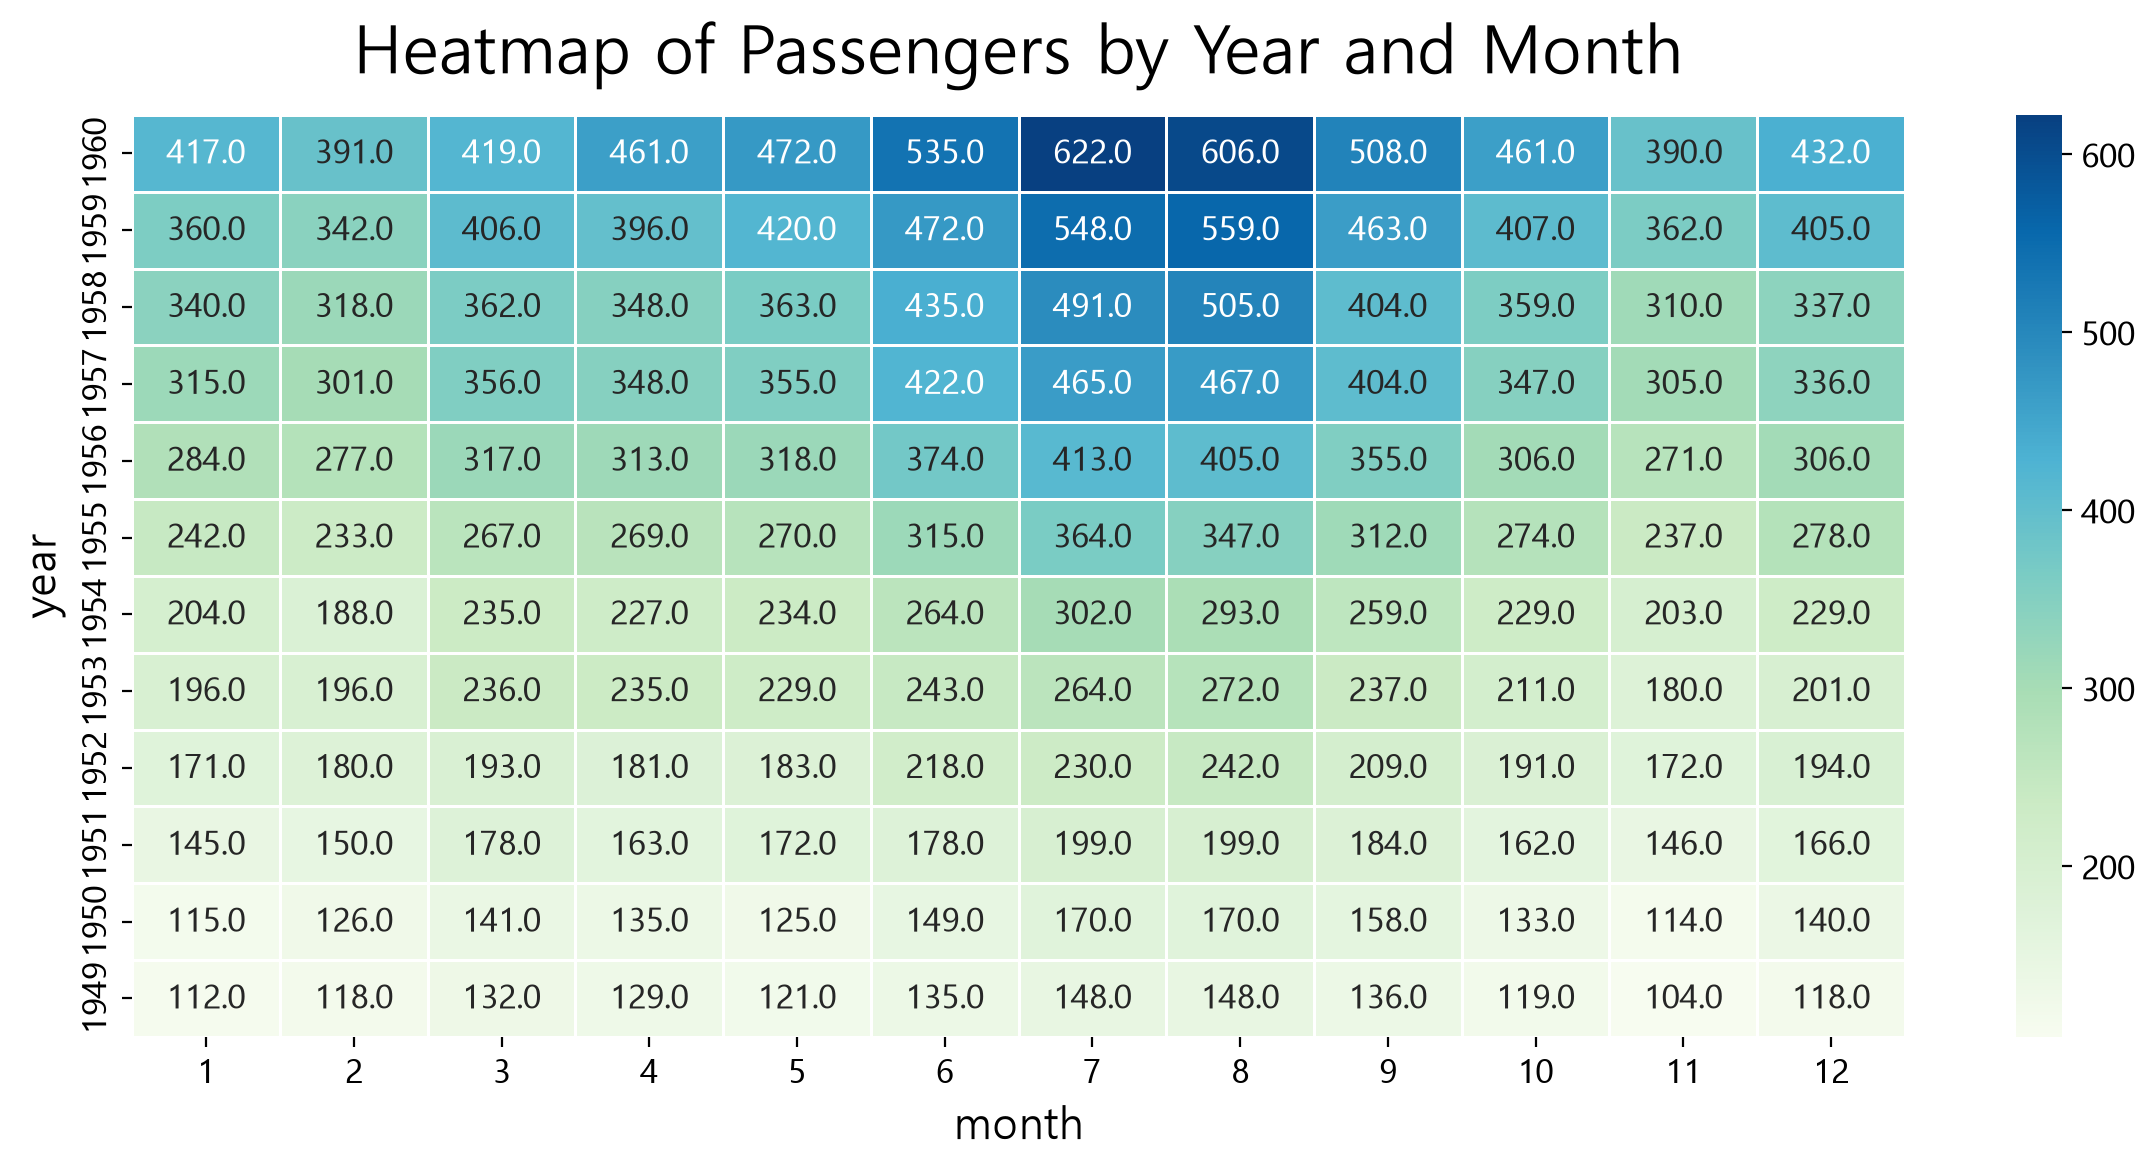

In [6]:
fig, ax = my_plot.init(width=1200, height=600, 
                       title="Heatmap of Passengers by Year and Month", 
                       xlabel="Montth", ylabel="Year")

ax.grid(False) # 격자 제거 

# 2) heatmap 그리기 
# -> annot = True : 수치값을 함께 표시함 
# -> fmt : annot = True가 설정된 경우 표시되는 수치값의 형식 지정 
# -> linewidth : 각 셀 사이의 선 굵기 
# -> cmap : 칼라맵 ('Greys' 등) 
sb.heatmap(data=df3, annot=True, fmt="0.1f", linewidths=0.5, cmap="GnBu")   

my_plot.show()

## #03. 모듈화 기능 확인 

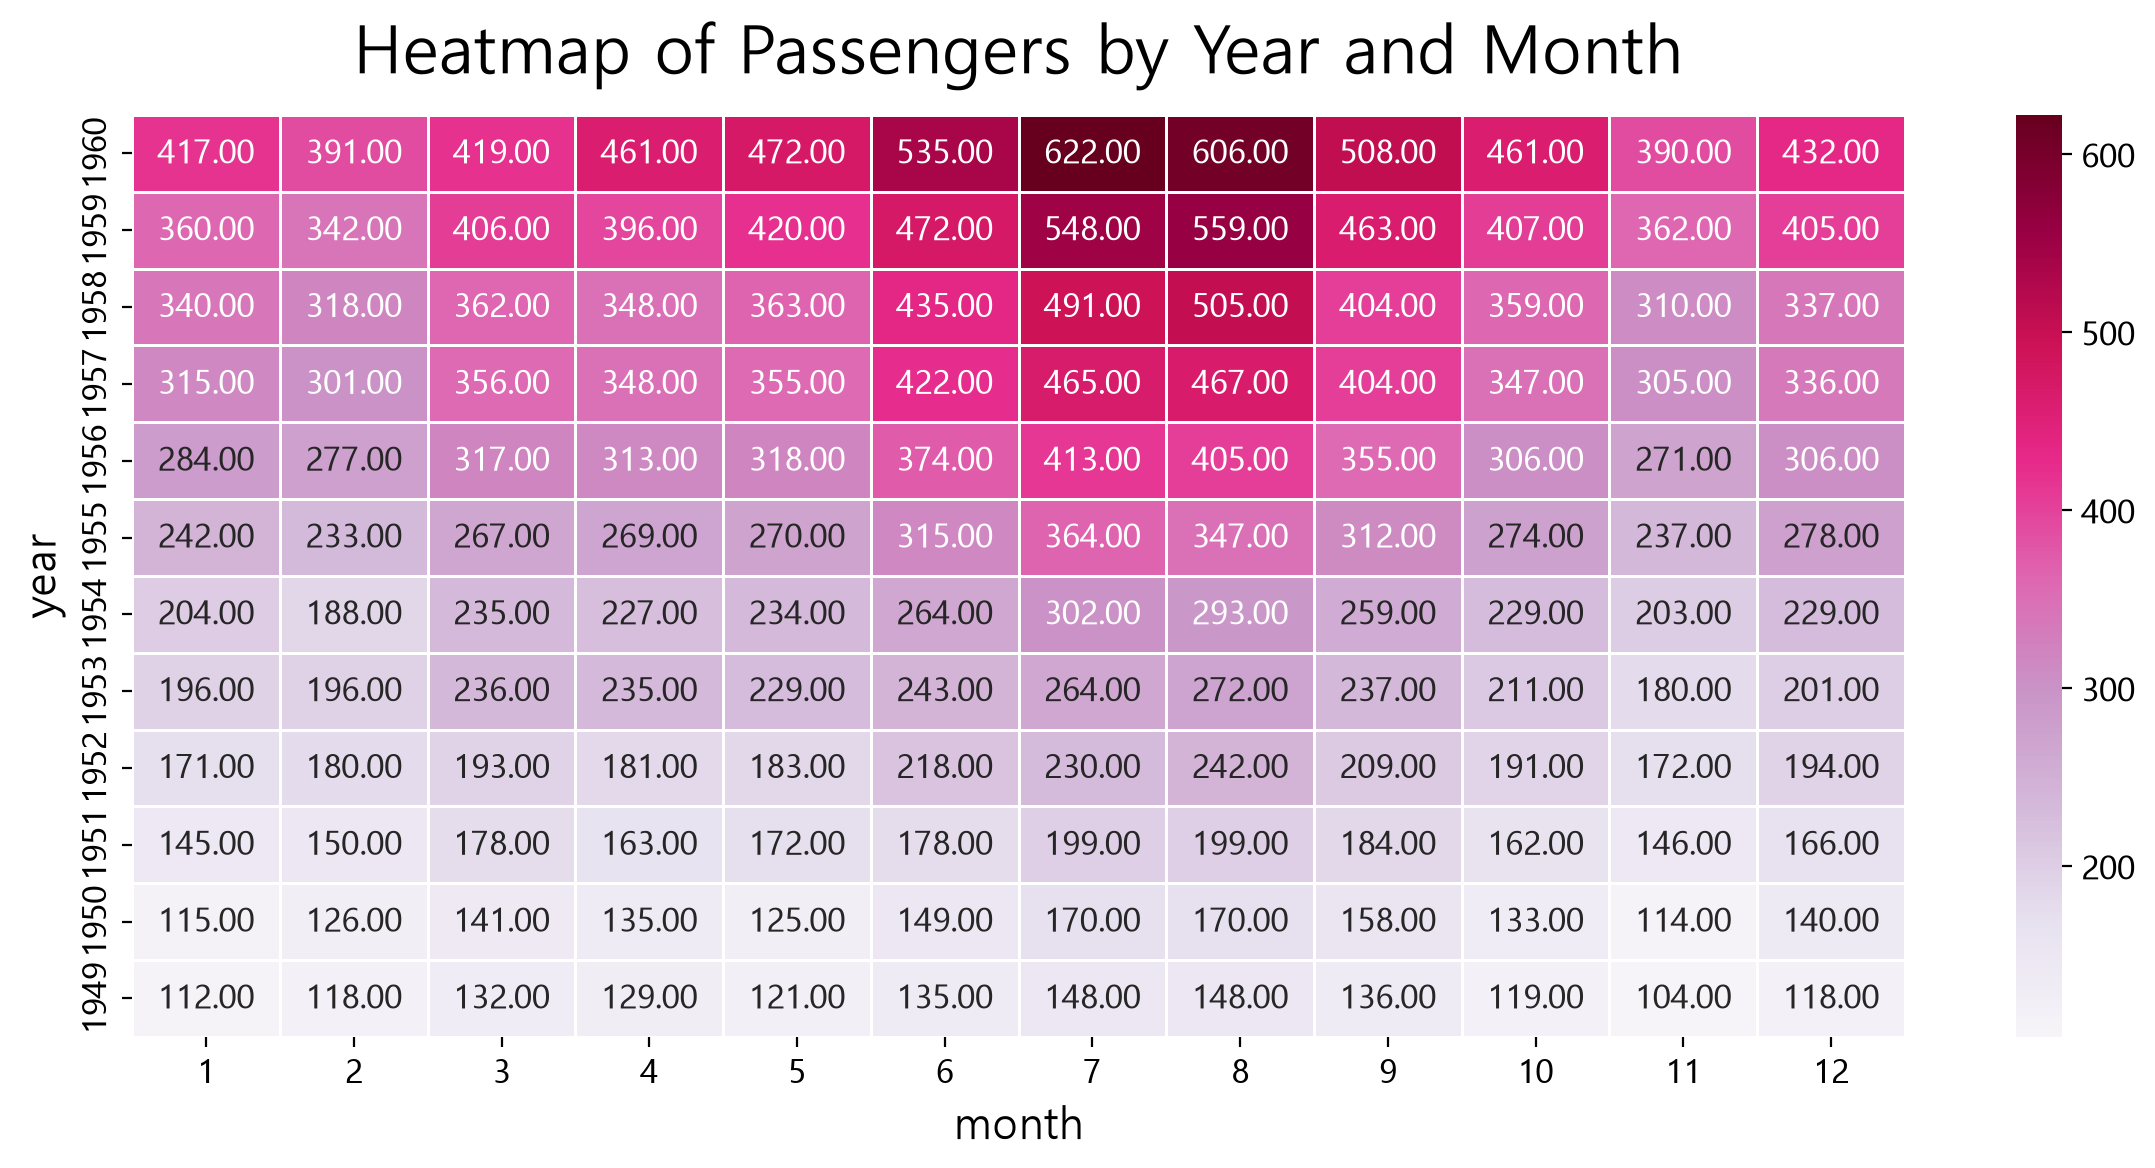

In [7]:
my_plot.heatmap(df3, palette="PuRd", width=1200, height=600, 
                title="Heatmap of Passengers by Year and Month", 
                xlabel="Month", ylabel="Year")

## #01. 연습문제 

In [8]:
from jussam import load_data
from helpers import * 
from pandas import pivot_table
import seaborn as sb

In [9]:
origin = load_data('traffic_acc')
origin.head()

📚 2005년 1월 부터 2018년 12월 까지 월별 교통사고의 발생건수,부상자수,사망자수 데이터(인덱스/메타데이터 없음, 출처: 공공데이터포털)


,년도,월,발생건수,사망자수,부상자수
0,2005,1,15494,504,25413
1,2005,2,13244,431,21635
2,2005,3,16580,477,25550
3,2005,4,17817,507,28131
4,2005,5,19085,571,29808


### 년도에 따른 월별 교통사고 발생건수 

In [10]:
df = origin.copy()

df = pivot_table(df, index="년도", columns="월", values="발생건수", aggfunc="mean")

df

월,1,2,3,4,5,6,7,8,9,10,11,12
년도,,,,,,,,,,,,
2005,15494.000,13244.000,16580.000,17817.000,19085.000,18092.000,18675.000,19035.000,18759.000,19757.000,19129.000,18504.000
2006,14971.000,14270.000,16767.000,17948.000,19140.000,17435.000,18634.000,18794.000,19293.000,19100.000,19877.000,17516.000
2007,14914.000,14696.000,18166.000,18055.000,19264.000,18310.000,18037.000,17982.000,18506.000,19026.000,17815.000,16891.000
2008,14741.000,14176.000,16752.000,17498.000,19515.000,18824.000,19562.000,18545.000,18023.000,19926.000,19597.000,18663.000
2009,16532.000,15502.000,18224.000,19153.000,20237.000,19249.000,20281.000,19993.000,21004.000,21440.000,20156.000,20219.000
2010,17124.000,15803.000,17801.000,18386.000,20372.000,18910.000,18965.000,19383.000,19439.000,21575.000,20271.000,18849.000
2011,16454.000,14208.000,16832.000,18570.000,19414.000,18505.000,19253.000,18896.000,19065.000,20952.000,20283.000,19279.000
2012,16818.000,16656.000,18255.000,19372.000,19672.000,18854.000,19333.000,18407.000,19234.000,19557.000,19750.000,17748.000
2013,16016.000,14187.000,17465.000,18031.000,19686.000,18329.000,18441.000,18691.000,17806.000,19797.000,19396.000,17509.000


### 데이터 시각화 

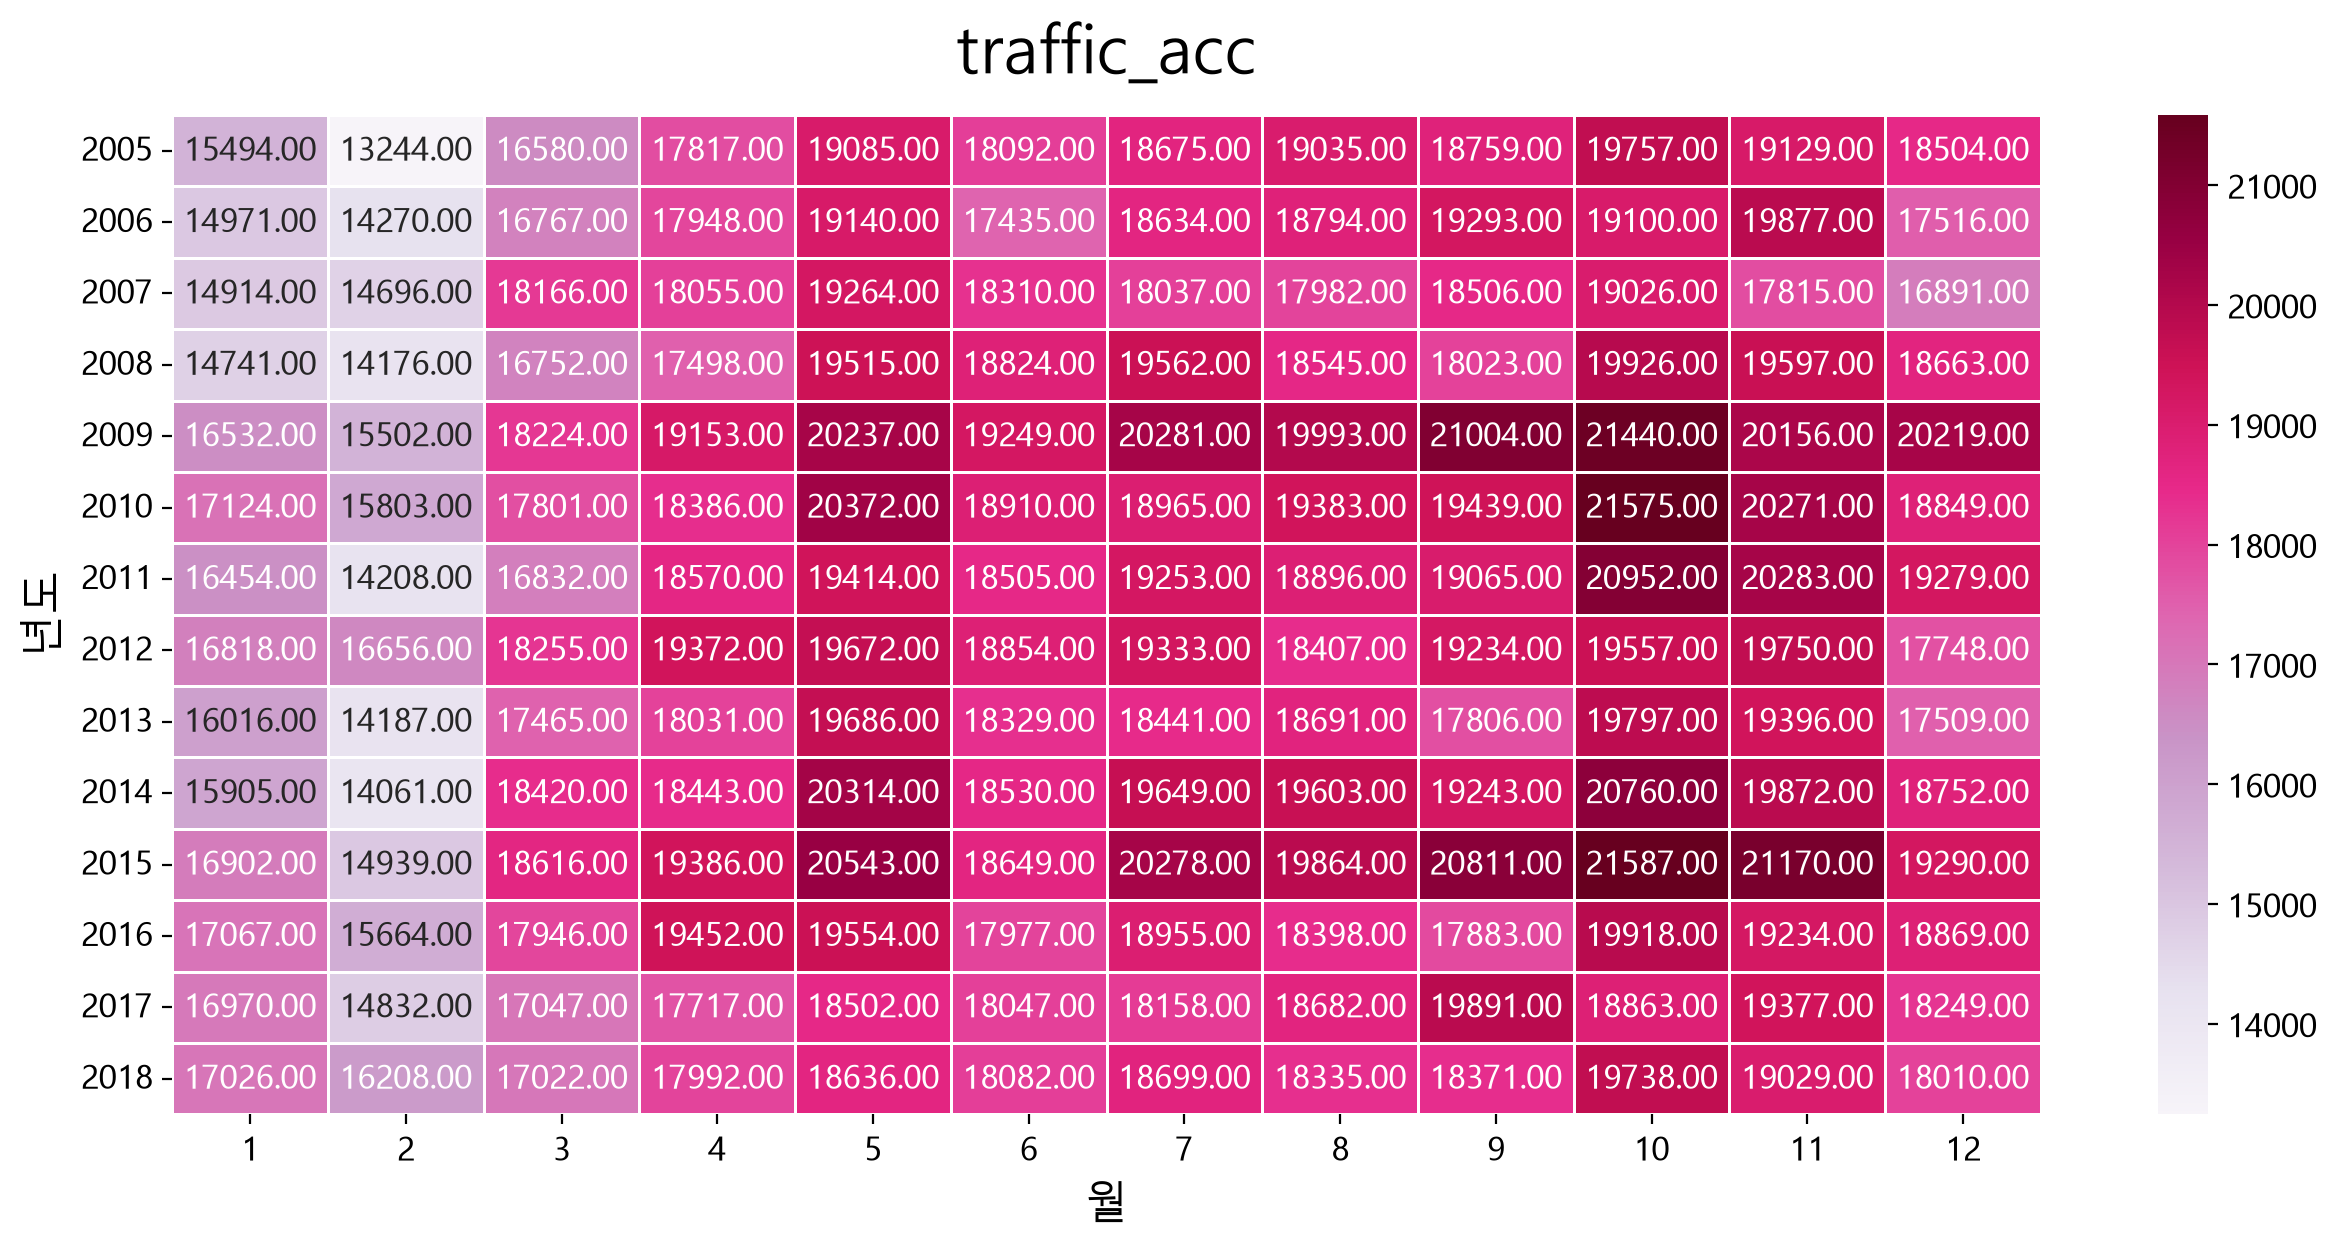

In [11]:
my_plot.heatmap(df, palette="PuRd",
                title="traffic_acc", 
                xlabel="월", ylabel="년도")

In [12]:
df2 = origin.copy()

df2 = pivot_table(df2, index="년도", columns="월", values="사망자수", aggfunc="mean")

df2

월,1,2,3,4,5,6,7,8,9,10,11,12
년도,,,,,,,,,,,,
2005,504.000,431.000,477.000,507.000,571.000,476.000,528.000,562.000,577.000,639.000,574.000,530.000
2006,420.000,373.000,465.000,469.000,531.000,455.000,516.000,585.000,580.000,651.000,701.000,581.000
2007,468.000,446.000,476.000,460.000,516.000,538.000,503.000,512.000,532.000,582.000,565.000,568.000
2008,444.000,428.000,502.000,476.000,493.000,423.000,452.000,529.000,502.000,574.000,528.000,519.000
2009,475.000,405.000,468.000,439.000,519.000,433.000,454.000,514.000,500.000,592.000,522.000,517.000
2010,438.000,406.000,396.000,395.000,447.000,474.000,453.000,410.000,436.000,619.000,541.000,490.000
2011,395.000,339.000,338.000,429.000,393.000,415.000,462.000,472.000,474.000,520.000,514.000,478.000
2012,418.000,393.000,403.000,483.000,444.000,476.000,416.000,409.000,486.000,533.000,508.000,423.000
2013,389.000,335.000,409.000,380.000,420.000,436.000,444.000,412.000,430.000,499.000,479.000,459.000


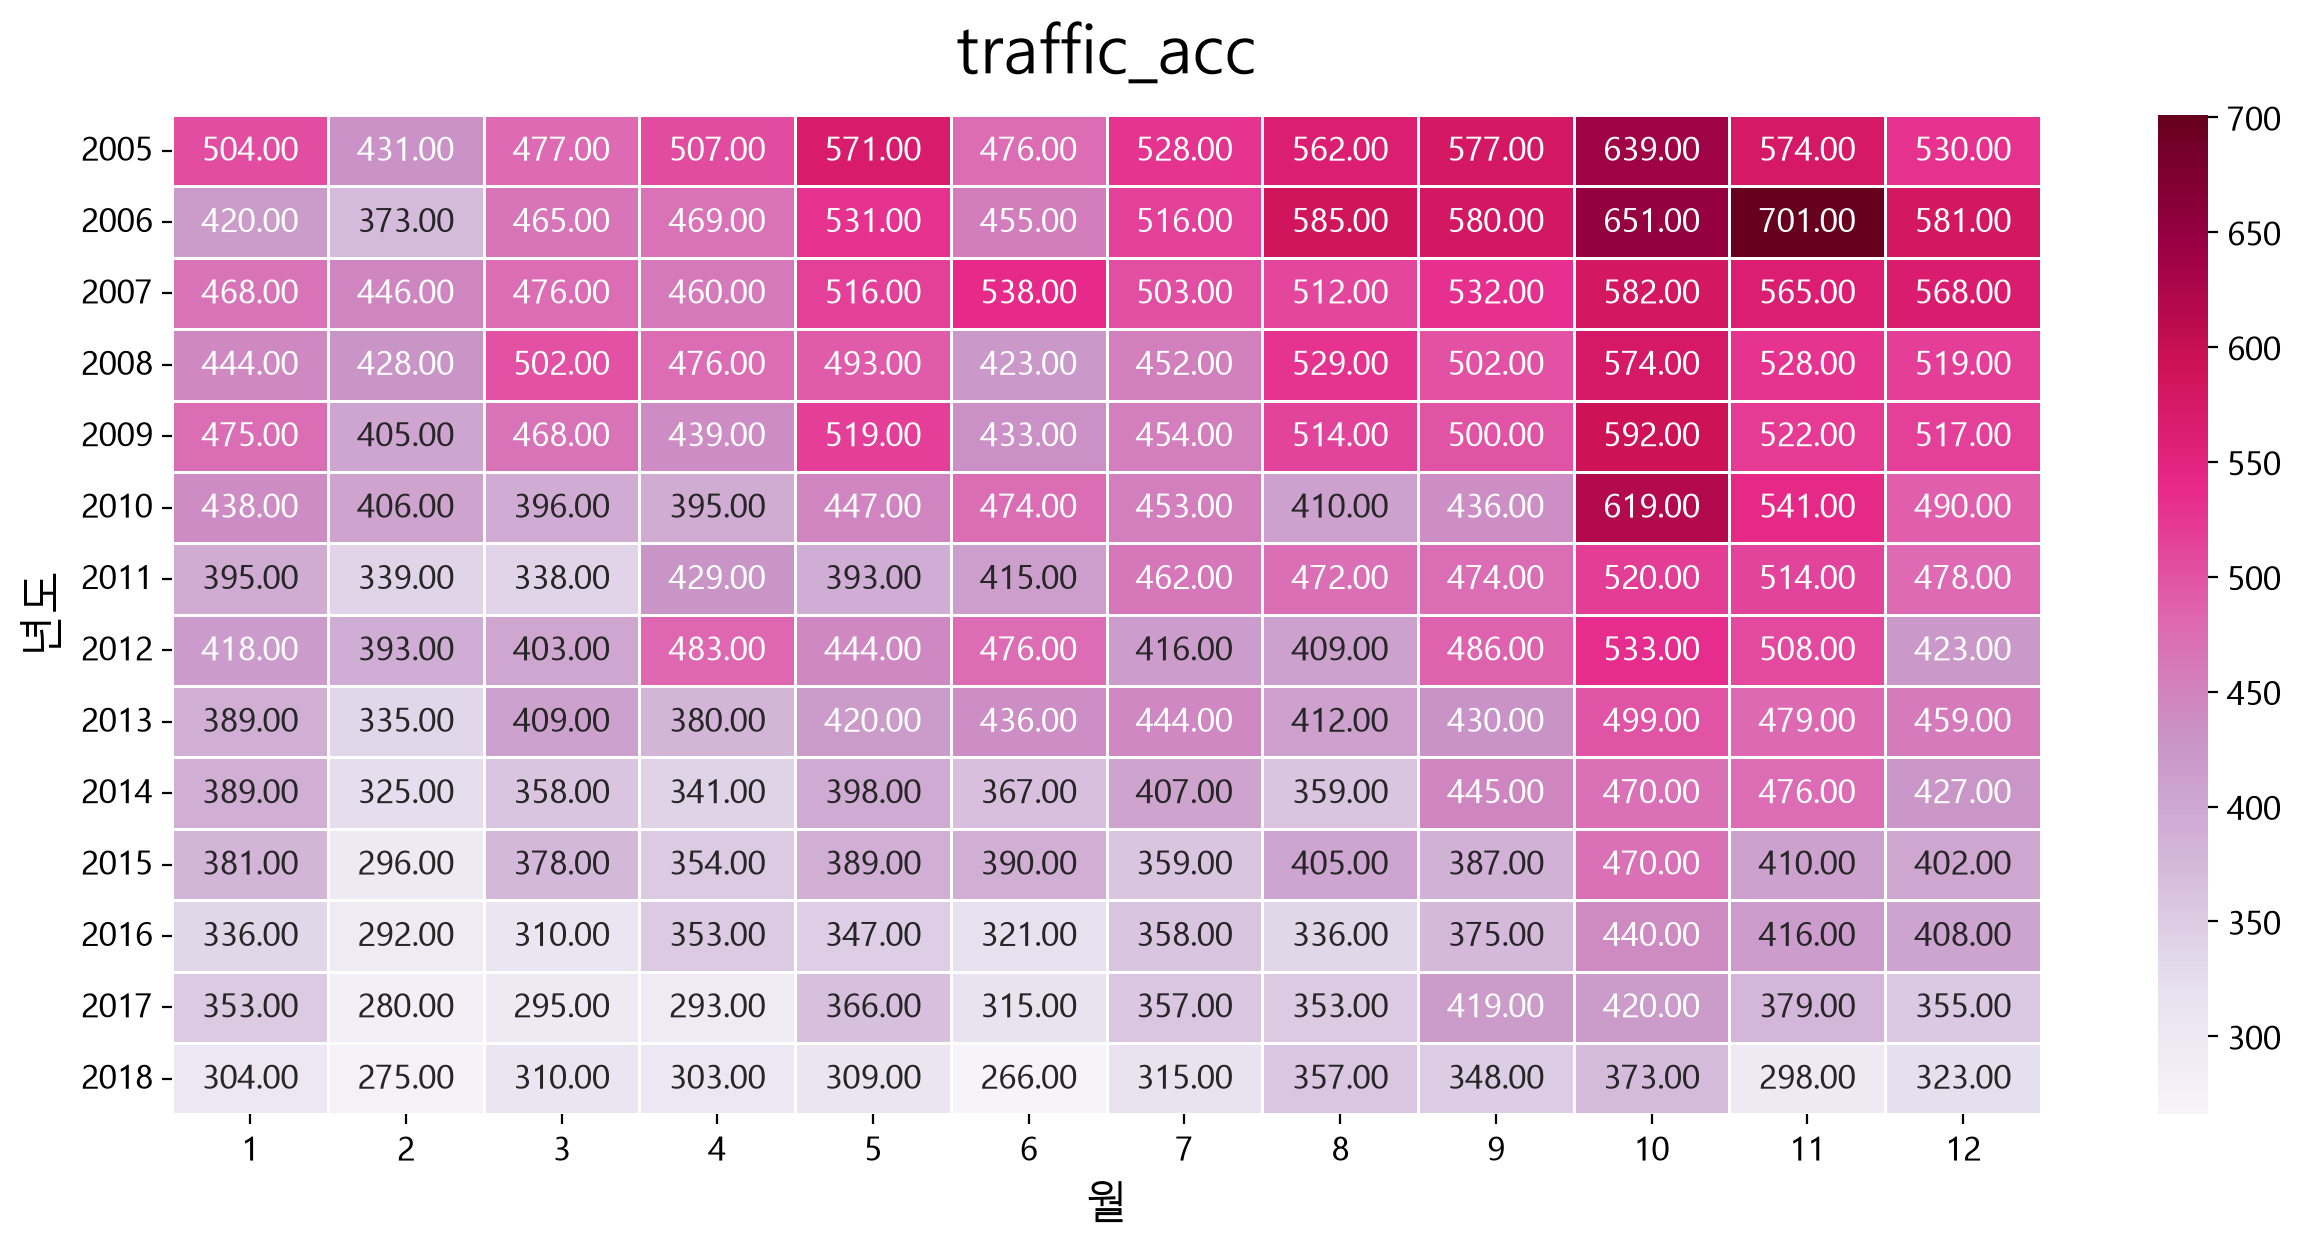

In [13]:
my_plot.heatmap(df2, palette="PuRd",
                title="traffic_acc", 
                xlabel="월", ylabel="년도")